
STEP 1: Generating Sample Dataset...



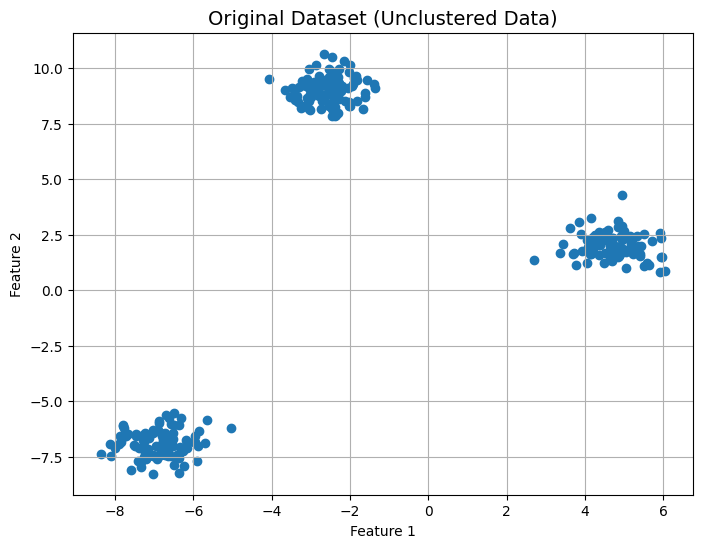

This graph shows the original data before clustering.


STEP 2: Applying K-Means Clustering...



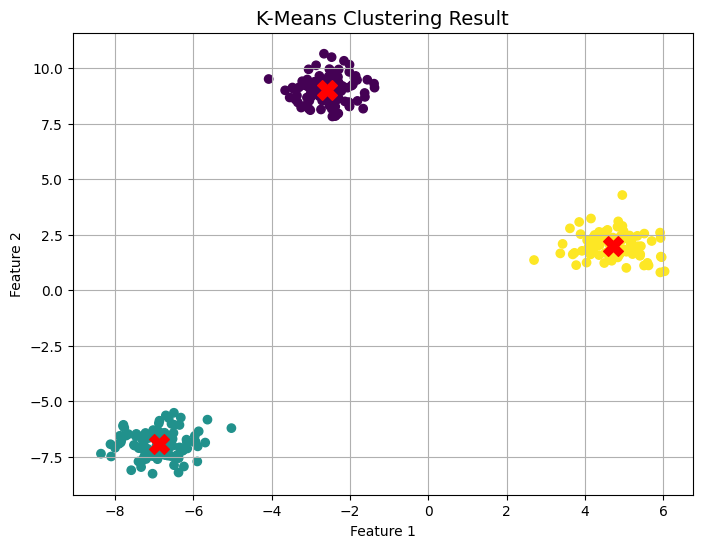

Clusters are formed using K-Means.
Red 'X' marks represent cluster centroids.


STEP 3: Finding Optimal K using Elbow Method...



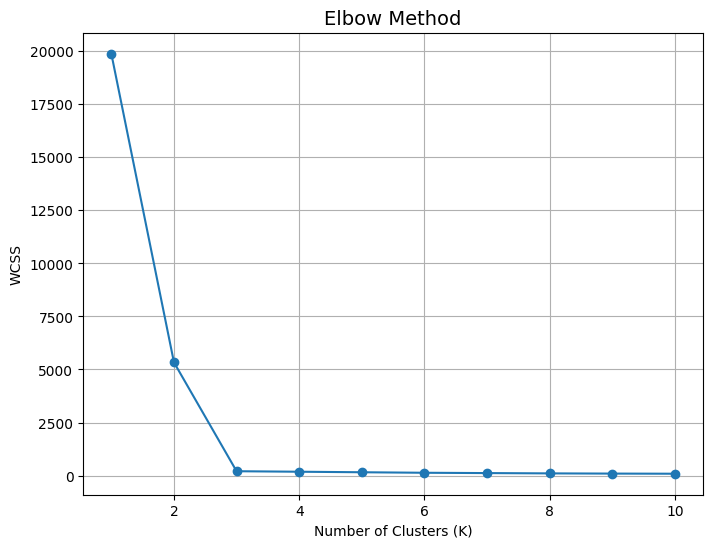

The 'elbow point' suggests optimal number of clusters.


STEP 4: Creating Clean Dendrogram...



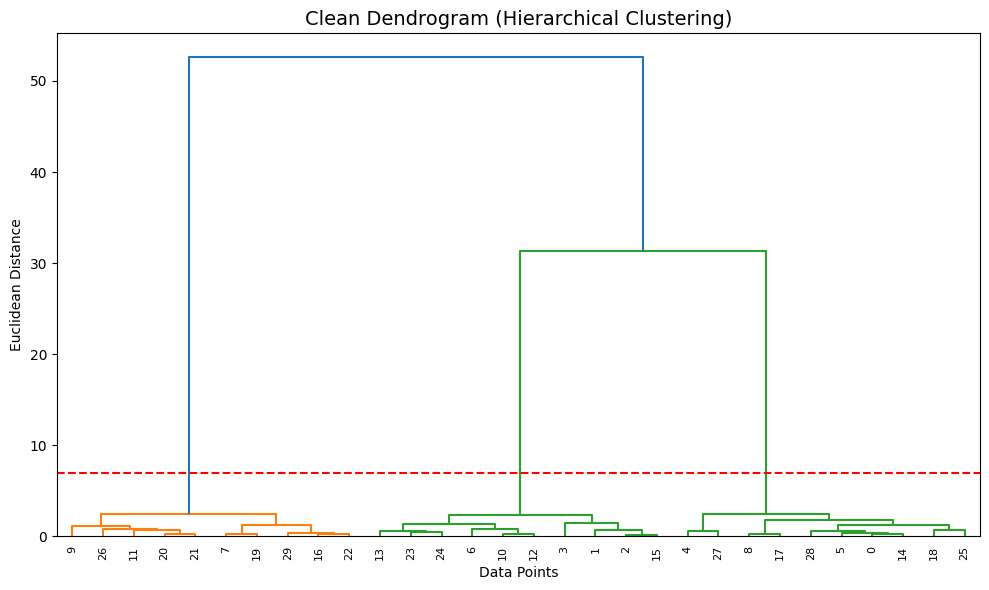

Horizontal red line shows where we cut to form clusters.


STEP 5: Applying Agglomerative Clustering...



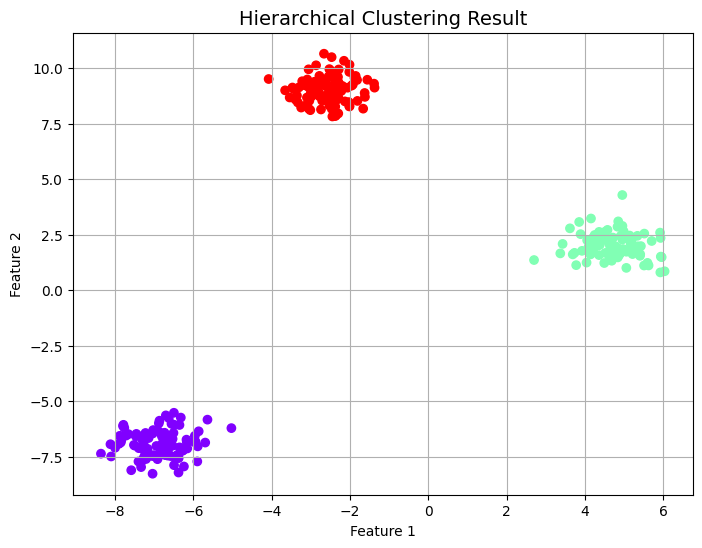

Final clusters formed using Hierarchical Clustering.



In [3]:
# ============================================================
# EXPERIMENT 6
# K-Means and Hierarchical Clustering (Improved Dendrogram)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage

# ------------------------------------------------------------
# STEP 1: Generate Sample Dataset
# ------------------------------------------------------------
print("\nSTEP 1: Generating Sample Dataset...\n")

X, y = make_blobs(n_samples=300,
                  centers=3,
                  cluster_std=0.60,
                  random_state=42)

plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Dataset (Unclustered Data)", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

print("This graph shows the original data before clustering.\n")


# ------------------------------------------------------------
# STEP 2: Apply K-Means Clustering
# ------------------------------------------------------------
print("\nSTEP 2: Applying K-Means Clustering...\n")

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X')
plt.title("K-Means Clustering Result", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

print("Clusters are formed using K-Means.")
print("Red 'X' marks represent cluster centroids.\n")


# ------------------------------------------------------------
# STEP 3: Elbow Method
# ------------------------------------------------------------
print("\nSTEP 3: Finding Optimal K using Elbow Method...\n")

wcss = []

for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method", fontsize=14)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

print("The 'elbow point' suggests optimal number of clusters.\n")


# ------------------------------------------------------------
# STEP 4: Clean Hierarchical Clustering - Dendrogram
# ------------------------------------------------------------
print("\nSTEP 4: Creating Clean Dendrogram...\n")

# Use smaller dataset for clarity
X_small, _ = make_blobs(n_samples=30,
                        centers=3,
                        cluster_std=0.60,
                        random_state=42)

linked = linkage(X_small, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked,
           leaf_rotation=90,
           leaf_font_size=8)

# Add horizontal cut line (for 3 clusters)
plt.axhline(y=7, color='red', linestyle='--')

plt.title("Clean Dendrogram (Hierarchical Clustering)", fontsize=14)
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.show()

print("Horizontal red line shows where we cut to form clusters.\n")


# ------------------------------------------------------------
# STEP 5: Apply Agglomerative Clustering
# ------------------------------------------------------------
print("\nSTEP 5: Applying Agglomerative Clustering...\n")

hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X)

plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=hc_labels, cmap='rainbow')
plt.title("Hierarchical Clustering Result", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

print("Final clusters formed using Hierarchical Clustering.\n")